# Preprocessing & Baseline Models
**DS340 — Multiclass Genre Classification**

Baseline models: Logistic Regression, Random Forest, KNN

Evaluated on: Accuracy, Macro F1, per-class classification report

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import warnings
warnings.filterwarnings('ignore')

print('Imports loaded.')

Imports loaded.


---
## 1. Load & Clean Data

In [3]:
data = pd.read_csv('../Data/spotify-tracks-dataset.csv')
print(f'Original shape: {data.shape}')

# drop identifier / index columns
drop_cols = ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
data = data.drop(columns=[c for c in drop_cols if c in data.columns])

# drop nulls and exact duplicates
data = data.dropna()
data = data.drop_duplicates()
print(f'After cleaning: {data.shape}')
print(f'Genres: {data["track_genre"].nunique()}')

Original shape: (114000, 22)
After cleaning: (106907, 16)
Genres: 114


In [4]:
# sample 300 tracks per genre to keep memory low for Codespace
sampled = data.groupby('track_genre').sample(n=300, random_state=42)
print(f'Sampled shape: {sampled.shape}')

# free original dataframe
del data
gc.collect()

sampled.head()

Sampled shape: (34200, 16)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
795,27,175336,False,0.709,0.156,3,-17.424,1,0.0357,0.9240,0.000078,0.0895,0.188,109.799,4,acoustic
83,0,181400,False,0.479,0.541,0,-9.862,1,0.0543,0.7400,0.000000,0.1080,0.300,85.994,4,acoustic
883,58,157600,False,0.507,0.399,9,-10.917,0,0.0358,0.8710,0.000377,0.1130,0.225,115.588,4,acoustic
512,37,198040,False,0.751,0.565,5,-9.106,1,0.0513,0.0777,0.012100,0.0855,0.679,119.996,4,acoustic
671,47,149426,False,0.254,0.349,4,-10.020,0,0.0379,0.8500,0.000029,0.2340,0.303,170.214,3,acoustic


---
## 2. Encode Labels & Define Features

In [5]:
# encode genre labels
le = LabelEncoder()
sampled['genre_label'] = le.fit_transform(sampled['track_genre'])
num_classes = len(le.classes_)
print(f'Number of classes: {num_classes}')

# select audio features
feature_cols = [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

X = sampled[feature_cols].copy()
X['explicit'] = X['explicit'].astype(int)
y = sampled['genre_label'].values

# free sampled df
del sampled
gc.collect()

print(f'X shape: {X.shape}, y shape: {y.shape}')

Number of classes: 114
X shape: (34200, 15), y shape: (34200,)


---
## 3. Train / Validation / Test Split + Scaling

In [6]:
# 70 / 15 / 15 split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

del X, X_temp, y_temp
gc.collect()

print(f'Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

Train: 23,940  Val: 5,130  Test: 5,130


In [7]:
# standardize (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print('Scaling done.')

Scaling done.


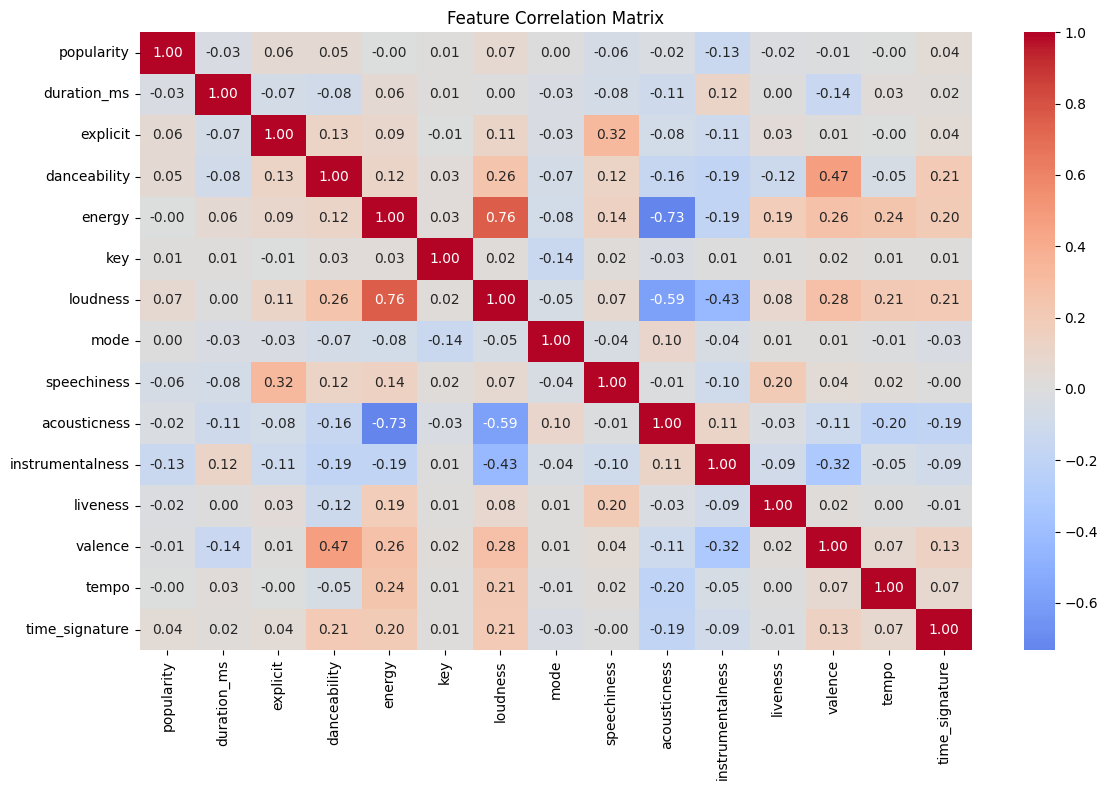

In [8]:
# feature correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    pd.DataFrame(X_train_sc, columns=feature_cols).corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 4. Baseline Models
Each model is trained, evaluated, then deleted from memory before the next one.

In [9]:
# store results
baseline_results = []

In [ ]:
# Logistic Regression 
print('Training Logistic Regression')
lr = LogisticRegression(max_iter=300, solver='saga', random_state=42)
lr.fit(X_train_sc, y_train)

lr_preds = lr.predict(X_val_sc)
lr_acc = accuracy_score(y_val, lr_preds)
lr_f1 = f1_score(y_val, lr_preds, average='macro')
print(f'  Accuracy: {lr_acc:.4f}, Macro F1: {lr_f1:.4f}')

baseline_results.append({'Model': 'Logistic Regression', 'Accuracy': lr_acc, 'Macro F1': lr_f1, 'preds': lr_preds})

# free model from memory
del lr

Training Logistic Regression...
  Accuracy: 0.1969, Macro F1: 0.1699
Done. Model freed from memory.


In [ ]:
# Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf.fit(X_train_sc, y_train)

rf_preds = rf.predict(X_val_sc)
rf_acc = accuracy_score(y_val, rf_preds)
rf_f1 = f1_score(y_val, rf_preds, average='macro')
print(f'  Accuracy: {rf_acc:.4f}, Macro F1: {rf_f1:.4f}')

baseline_results.append({'Model': 'Random Forest', 'Accuracy': rf_acc, 'Macro F1': rf_f1, 'preds': rf_preds})

del rf
gc.collect()
print('Done. Model freed from memory.')

Training Random Forest...
  Accuracy: 0.3019, Macro F1: 0.2834
Done. Model freed from memory.


In [ ]:
# K-Nearest Neighbors
print('Training KNN...')
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_sc, y_train)

knn_preds = knn.predict(X_val_sc)
knn_acc = accuracy_score(y_val, knn_preds)
knn_f1 = f1_score(y_val, knn_preds, average='macro')
print(f'  Accuracy: {knn_acc:.4f}, Macro F1: {knn_f1:.4f}')

baseline_results.append({'Model': 'KNN (k=15)', 'Accuracy': knn_acc, 'Macro F1': knn_f1, 'preds': knn_preds})

del knn

Training KNN...
  Accuracy: 0.1789, Macro F1: 0.1672
Done. Model freed from memory.


---
## 5. Compare Baselines

In [13]:
results_df = pd.DataFrame(baseline_results)[['Model', 'Accuracy', 'Macro F1']]
print('=== Baseline Comparison (Validation Set) ===')
print(results_df.to_string(index=False))

=== Baseline Comparison (Validation Set) ===
              Model  Accuracy  Macro F1
Logistic Regression  0.196881  0.169857
      Random Forest  0.301949  0.283377
         KNN (k=15)  0.178947  0.167236


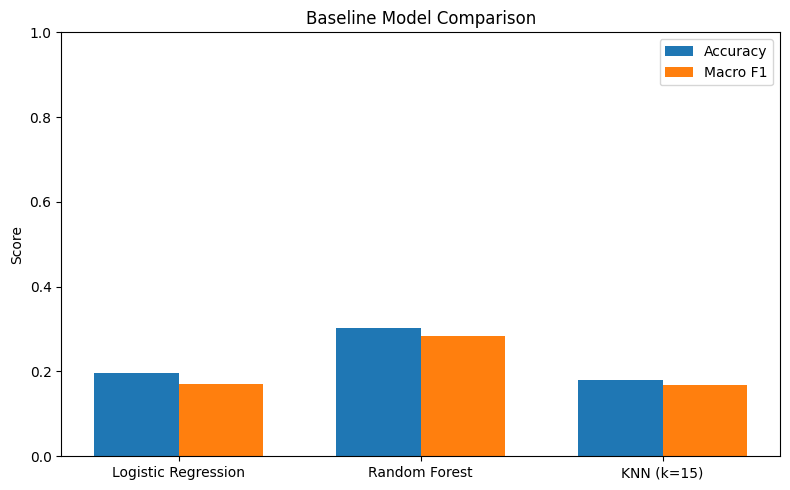

In [14]:
# bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy')
ax.bar(x + width/2, results_df['Macro F1'], width, label='Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# classification report for best baseline
best = max(baseline_results, key=lambda r: r['Macro F1'])
print(f'Best baseline: {best["Model"]}\n')
print(classification_report(y_val, best['preds'], target_names=le.classes_))

Best baseline: Random Forest

                   precision    recall  f1-score   support

         acoustic       0.29      0.24      0.27        45
         afrobeat       0.34      0.33      0.34        45
         alt-rock       0.05      0.02      0.03        45
      alternative       0.11      0.09      0.10        45
          ambient       0.24      0.22      0.23        45
            anime       0.17      0.11      0.13        45
      black-metal       0.48      0.53      0.51        45
        bluegrass       0.34      0.49      0.40        45
            blues       0.07      0.02      0.03        45
           brazil       0.12      0.07      0.08        45
        breakbeat       0.53      0.38      0.44        45
          british       0.30      0.07      0.11        45
         cantopop       0.19      0.22      0.21        45
    chicago-house       0.49      0.47      0.48        45
         children       0.42      0.33      0.37        45
            chill       0

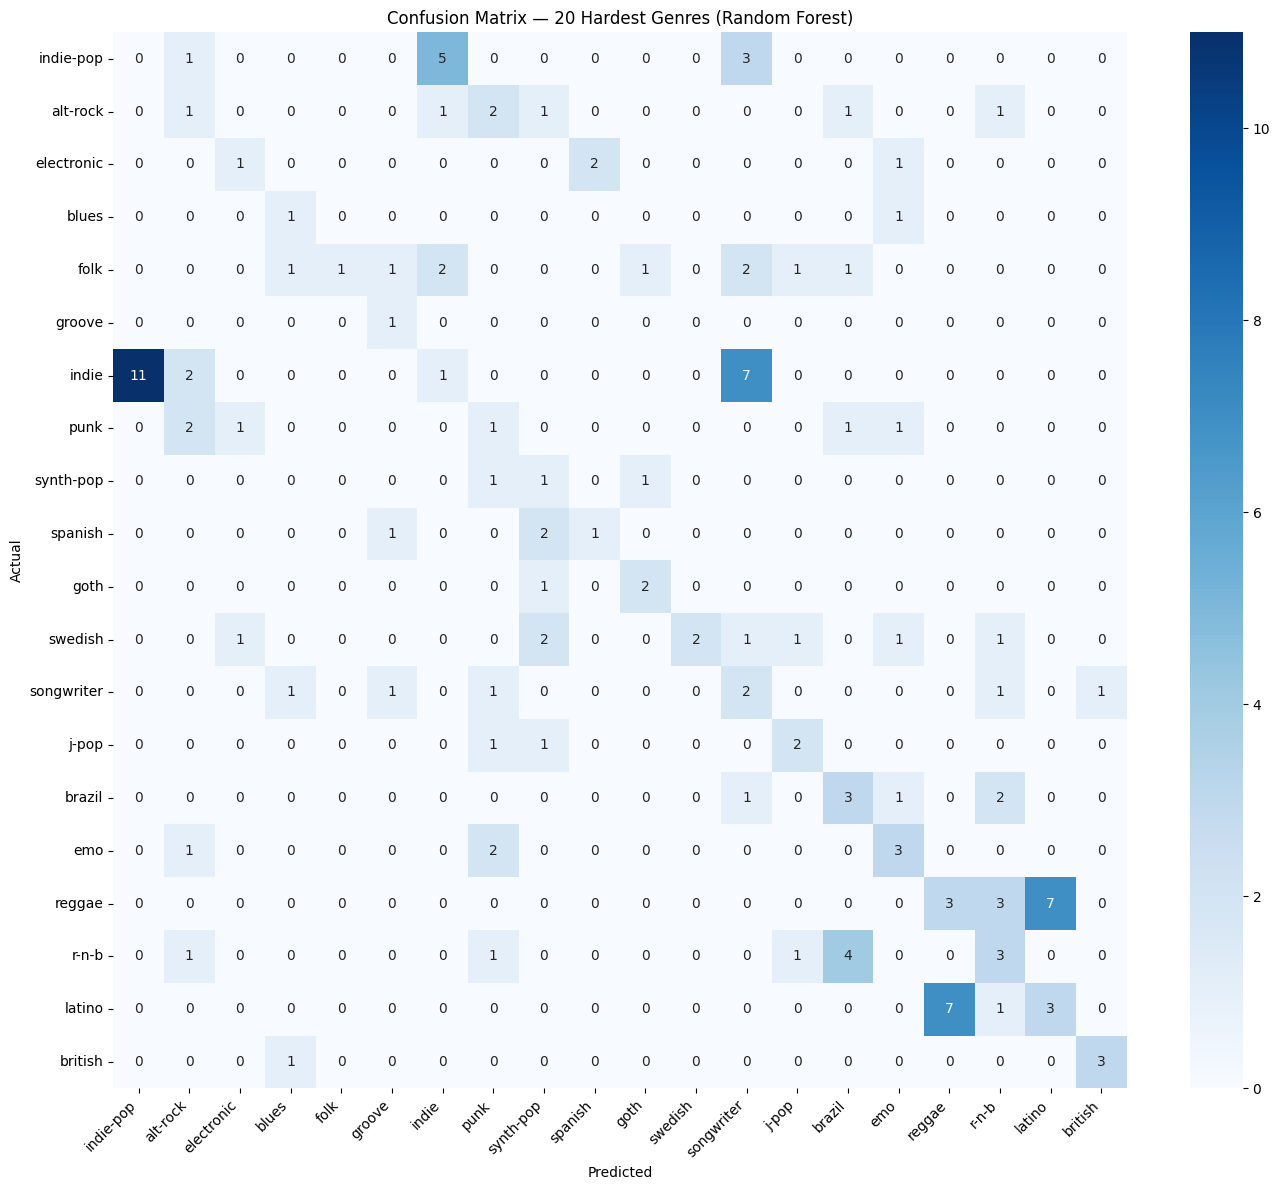


Per-class accuracy for 20 hardest genres:
  indie-pop                 0.000
  alt-rock                  0.022
  electronic                0.022
  blues                     0.022
  folk                      0.022
  groove                    0.022
  indie                     0.022
  punk                      0.022
  synth-pop                 0.022
  spanish                   0.022
  goth                      0.044
  swedish                   0.044
  songwriter                0.044
  j-pop                     0.044
  brazil                    0.067
  emo                       0.067
  reggae                    0.067
  r-n-b                     0.067
  latino                    0.067
  british                   0.067


In [16]:
# confusion matrix for best baseline (20 hardest genres)
cm = confusion_matrix(y_val, best['preds'])
per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_20 = np.argsort(per_class_acc)[:20]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm[np.ix_(worst_20, worst_20)],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_[worst_20],
    yticklabels=le.classes_[worst_20]
)
plt.title(f'Confusion Matrix — 20 Hardest Genres ({best["Model"]})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nPer-class accuracy for 20 hardest genres:')
for i in worst_20:
    print(f'  {le.classes_[i]:25s} {per_class_acc[i]:.3f}')

---
## Next Steps
- Build DNN in a separate notebook
- Compare DNN results against these baselines
- Hyperparameter tuning and feature subset experiments